C:\Users\HANIN\AppData\Local\Temp\ipykernel_24360\1325038334.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)


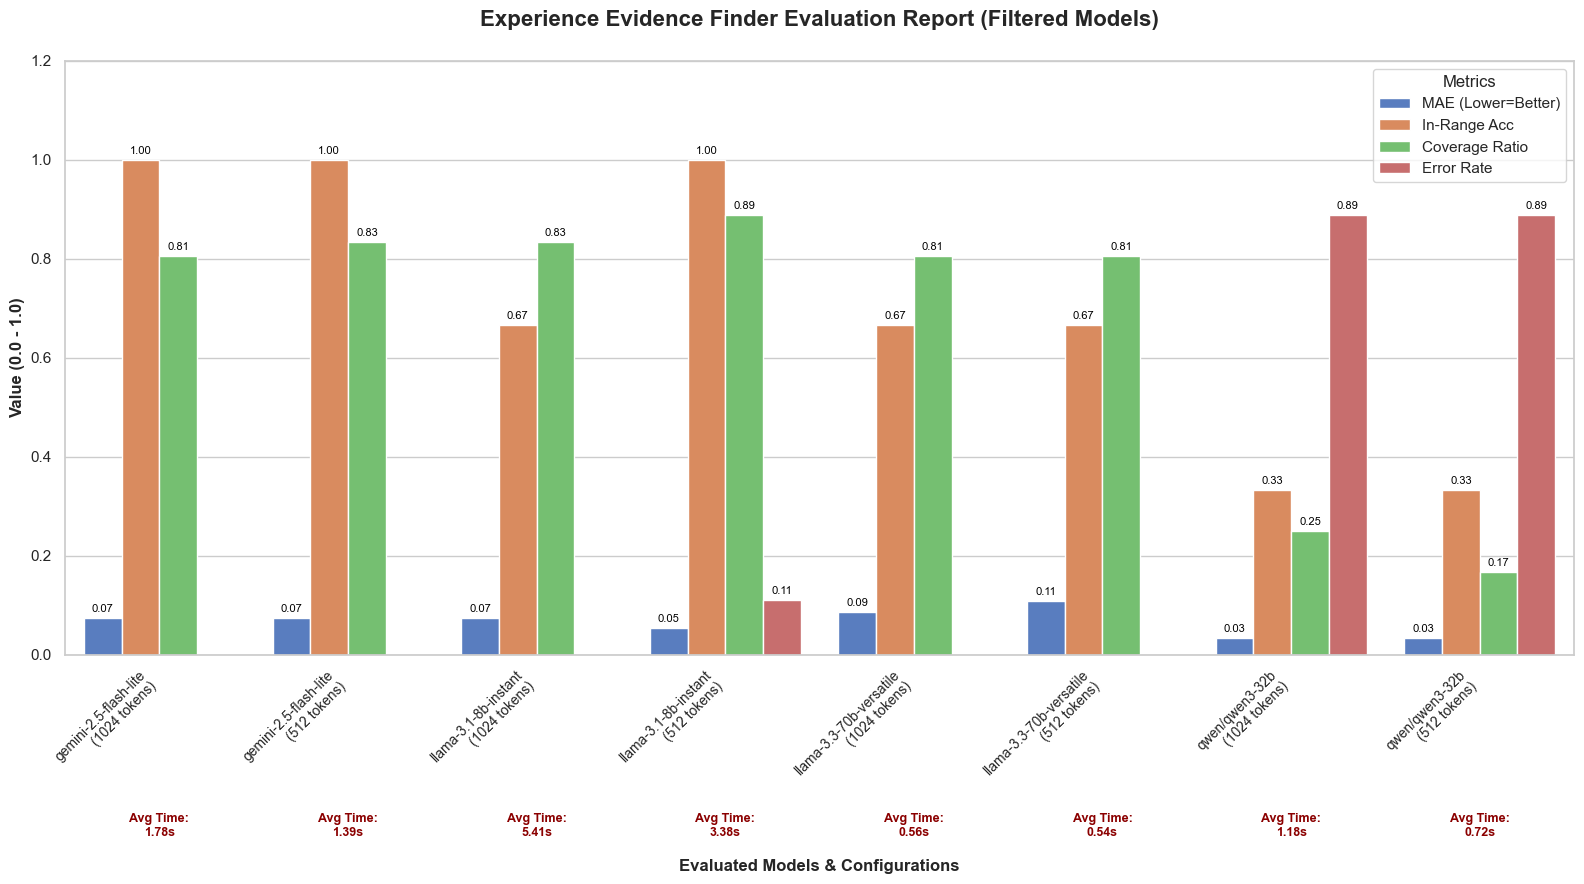

In [ ]:
import json
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

JSON_FILE_NAME = "json_results/bio_analysis.json"  

if not os.path.exists(JSON_FILE_NAME):
    raise FileNotFoundError(f"Result file {JSON_FILE_NAME} not found.")

with open(JSON_FILE_NAME, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

parsed_runs = []
for run in raw_data:
    model_name = run.get("model_name", "Unknown").split(":")[-1] 
    max_tokens = run.get("model_kwargs", {}).get("max_tokens", 0)
    results = run.get("results", {})
    
    model_tag = f"{model_name}\n({max_tokens} tokens)"
    
    parsed_runs.append({
        "Model": model_tag,
        "MAE (Lower=Better)": results.get("bio_score_mae", 0.0),
        "In-Range Acc": results.get("bio_score_in_range_accuracy", 0.0),
        "Coverage Ratio": results.get("bio_content_coverage_ratio", 0.0),
        "Error Rate": results.get("error_rate", 0.0),
        "Time (s)": results.get("agent_invocation_time", 0.0)
    })

df = pd.DataFrame(parsed_runs)

df_grouped = df.groupby("Model", as_index=False).mean()

# Filter out any model configurations where the average Error Rate is exactly 1.0
df_grouped = df_grouped[df_grouped["Error Rate"] < 1.0].reset_index(drop=True)

df_melted = pd.melt(
    df_grouped, 
    id_vars=["Model", "Time (s)"], 
    value_vars=["MAE (Lower=Better)", "In-Range Acc", "Coverage Ratio", "Error Rate"],
    var_name="Metric", 
    value_name="Score"
)

plt.figure(figsize=(16, 9))
sns.set_theme(style="whitegrid")

ax = sns.barplot(x="Model", y="Score", hue="Metric", data=df_melted, palette="muted")

for p in ax.patches:
    height = p.get_height()
    if height > 0.01:
        ax.annotate(f'{height:.2f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=8, color='black',
                    xytext=(0, 3),
                    textcoords='offset points')

plt.title("Experience Evidence Finder Evaluation Report (Filtered Models)", fontsize=16, fontweight='bold', pad=25)
plt.ylabel("Value (0.0 - 1.0)", fontsize=12, fontweight='bold')
plt.ylim(0, 1.2) 
plt.legend(title="Metrics", loc="upper right", frameon=True)

plt.xlabel("Evaluated Models & Configurations", fontsize=12, fontweight='bold', labelpad=50)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)

for idx, row in df_grouped.iterrows():
    ax.text(idx, -0.32, f"Avg Time:\n{row['Time (s)']:.2f}s", 
            ha='center', va='top', fontsize=9, color='darkred', fontweight='bold')

plt.subplots_adjust(bottom=0.28)
plt.tight_layout()

plt.show()

C:\Users\HANIN\AppData\Local\Temp\ipykernel_24360\4010469374.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)


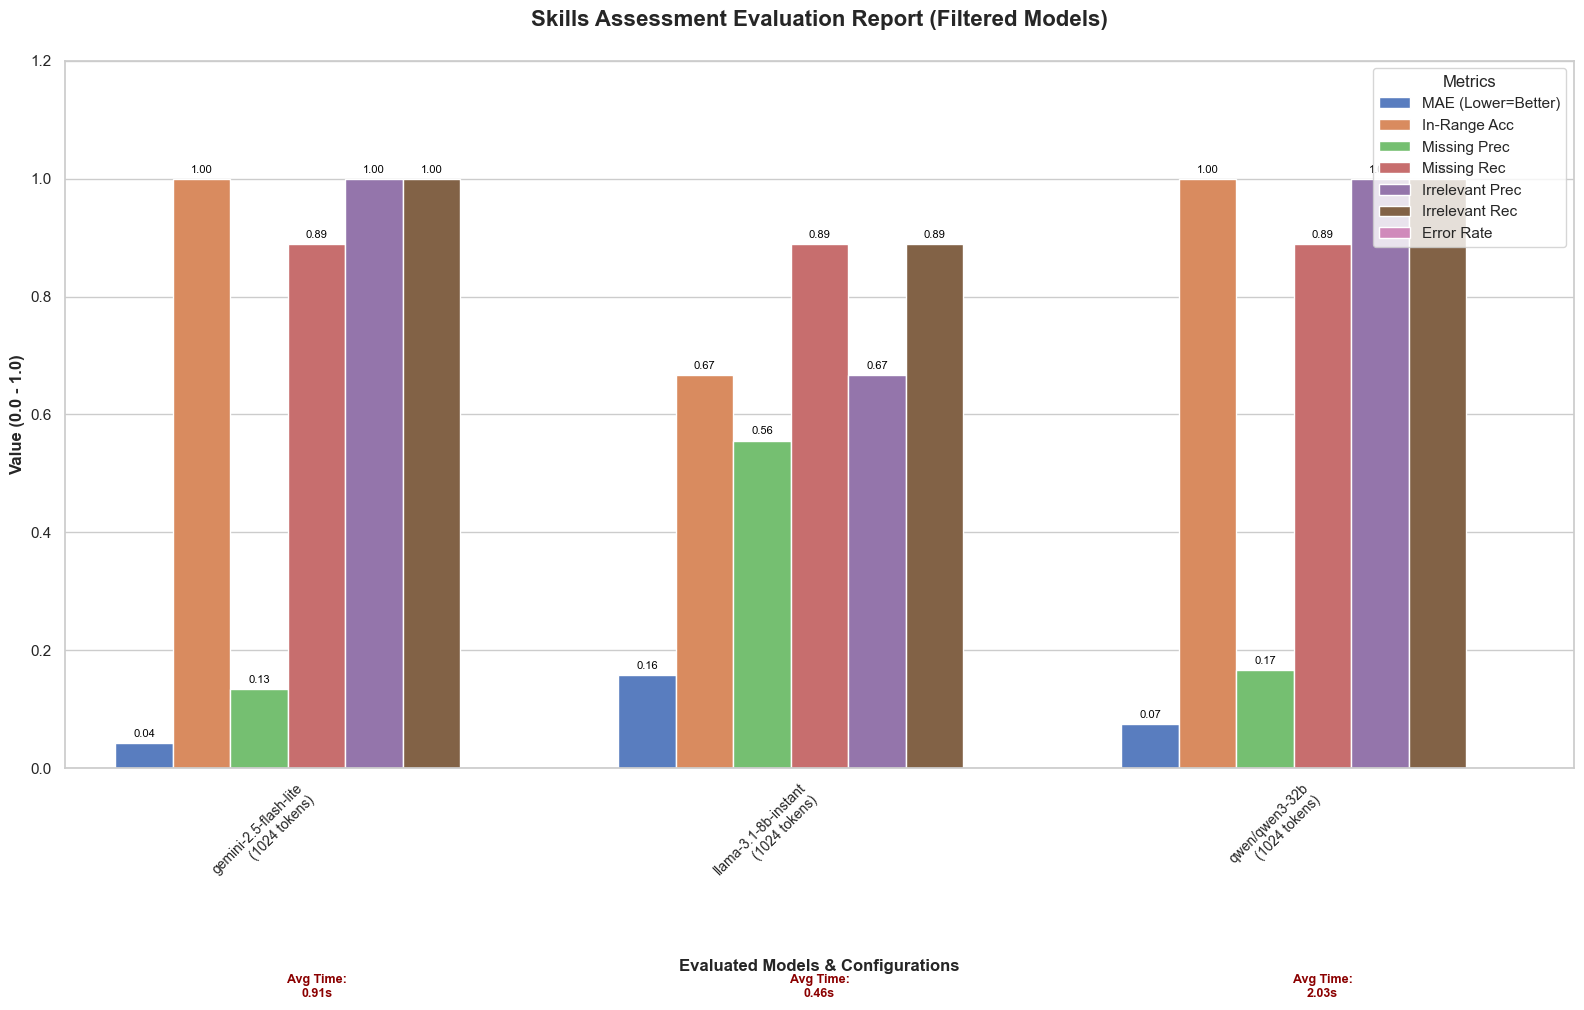

In [ ]:
import json
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

JSON_FILE_NAME = "json_results/skills_analysis.json"  

if not os.path.exists(JSON_FILE_NAME):
    raise FileNotFoundError(f"Result file {JSON_FILE_NAME} not found.")

with open(JSON_FILE_NAME, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

parsed_runs = []
for run in raw_data:
    model_name = run.get("model_name", "Unknown").split(":")[-1] 
    max_tokens = run.get("model_kwargs", {}).get("max_tokens", 0)
    results = run.get("results", {})
    
    model_tag = f"{model_name}\n({max_tokens} tokens)"
    
    parsed_runs.append({
        "Model": model_tag,
        "MAE (Lower=Better)": results.get("skills_score_mae", 0.0),
        "In-Range Acc": results.get("skills_score_in_range_accuracy", 0.0),
        "Missing Prec": results.get("missing_skills_precision", 0.0),
        "Missing Rec": results.get("missing_skills_recall", 0.0),
        "Irrelevant Prec": results.get("irrelevant_skills_precision", 0.0),
        "Irrelevant Rec": results.get("irrelevant_skills_recall", 0.0),
        "Error Rate": results.get("error_rate", 0.0),
        "Time (s)": results.get("agent_invocation_time", 0.0)
    })

df = pd.DataFrame(parsed_runs)

df_grouped = df.groupby("Model", as_index=False).mean()

# Filter out any model configurations where the average Error Rate is exactly 1.0
df_grouped = df_grouped[df_grouped["Error Rate"] < 1.0].reset_index(drop=True)

df_melted = pd.melt(
    df_grouped, 
    id_vars=["Model", "Time (s)"], 
    value_vars=[
        "MAE (Lower=Better)", "In-Range Acc", "Missing Prec", 
        "Missing Rec", "Irrelevant Prec", "Irrelevant Rec", "Error Rate"
    ],
    var_name="Metric", 
    value_name="Score"
)

plt.figure(figsize=(16, 10))
sns.set_theme(style="whitegrid")

ax = sns.barplot(x="Model", y="Score", hue="Metric", data=df_melted, palette="muted")

for p in ax.patches:
    height = p.get_height()
    if height > 0.01:
        ax.annotate(f'{height:.2f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=8, color='black',
                    xytext=(0, 3),
                    textcoords='offset points')

plt.title("Skills Assessment Evaluation Report (Filtered Models)", fontsize=16, fontweight='bold', pad=25)
plt.ylabel("Value (0.0 - 1.0)", fontsize=12, fontweight='bold')
plt.ylim(0, 1.2) 
plt.legend(title="Metrics", loc="upper right", frameon=True)

plt.xlabel("Evaluated Models & Configurations", fontsize=12, fontweight='bold', labelpad=50)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)

for idx, row in df_grouped.iterrows():
    ax.text(idx, -0.35, f"Avg Time:\n{row['Time (s)']:.2f}s", 
            ha='center', va='top', fontsize=9, color='darkred', fontweight='bold')

plt.subplots_adjust(bottom=0.32)
plt.tight_layout()

plt.show()

C:\Users\HANIN\AppData\Local\Temp\ipykernel_27464\3218037928.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)


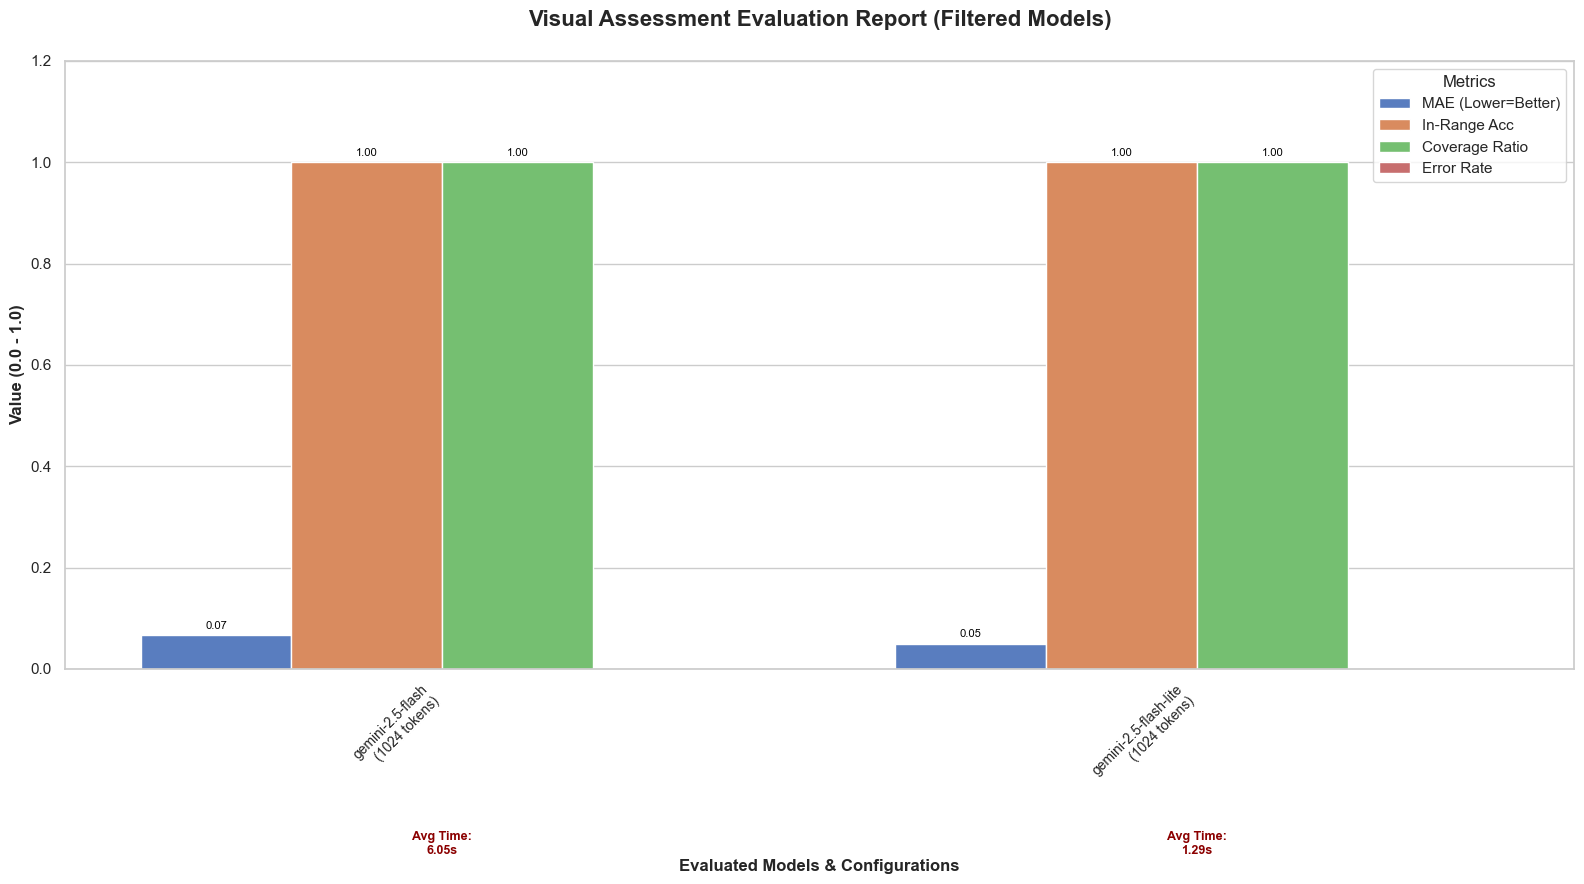

In [ ]:
import json
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

JSON_FILE_NAME = "json_results/visual_brand_analysis.json"  

if not os.path.exists(JSON_FILE_NAME):
    raise FileNotFoundError(f"Result file {JSON_FILE_NAME} not found.")

with open(JSON_FILE_NAME, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

parsed_runs = []
for run in raw_data:
    model_name = run.get("model_name", "Unknown").split(":")[-1] 
    max_tokens = run.get("model_kwargs", {}).get("max_tokens", 0)
    results = run.get("results", {})
    
    model_tag = f"{model_name}\n({max_tokens} tokens)"
    
    parsed_runs.append({
        "Model": model_tag,
        "MAE (Lower=Better)": results.get("visual_brand_score_mae", 0.0),
        "In-Range Acc": results.get("visual_brand_score_in_range_accuracy", 0.0),
        "Coverage Ratio": results.get("visual_brand_content_coverage_ratio", 0.0),
        "Error Rate": results.get("error_rate", 0.0),
        "Time (s)": results.get("agent_invocation_time", 0.0)
    })

df = pd.DataFrame(parsed_runs)

df_grouped = df.groupby("Model", as_index=False).mean()

df_grouped = df_grouped[df_grouped["Error Rate"] < 1.0].reset_index(drop=True)

if df_grouped.empty:
    print("Warning: All models have a 1.0 Error Rate. Creating plot with raw data to show errors.")
    df_grouped = df.groupby("Model", as_index=False).mean().reset_index(drop=True)

df_melted = pd.melt(
    df_grouped, 
    id_vars=["Model", "Time (s)"], 
    value_vars=["MAE (Lower=Better)", "In-Range Acc", "Coverage Ratio", "Error Rate"],
    var_name="Metric", 
    value_name="Score"
)

plt.figure(figsize=(16, 9))
sns.set_theme(style="whitegrid")

ax = sns.barplot(x="Model", y="Score", hue="Metric", data=df_melted, palette="muted")

for p in ax.patches:
    height = p.get_height()
    if height > 0.01:
        ax.annotate(f'{height:.2f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=8, color='black',
                    xytext=(0, 3),
                    textcoords='offset points')

plt.title("Visual Assessment Evaluation Report (Filtered Models)", fontsize=16, fontweight='bold', pad=25)
plt.ylabel("Value (0.0 - 1.0)", fontsize=12, fontweight='bold')
plt.ylim(0, 1.2) 
plt.legend(title="Metrics", loc="upper right", frameon=True)

plt.xlabel("Evaluated Models & Configurations", fontsize=12, fontweight='bold', labelpad=50)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)

for idx, row in df_grouped.iterrows():
    ax.text(idx, -0.32, f"Avg Time:\n{row['Time (s)']:.2f}s", 
            ha='center', va='top', fontsize=9, color='darkred', fontweight='bold')

plt.subplots_adjust(bottom=0.28)
plt.tight_layout()

plt.show()

C:\Users\HANIN\AppData\Local\Temp\ipykernel_8636\3994772507.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)


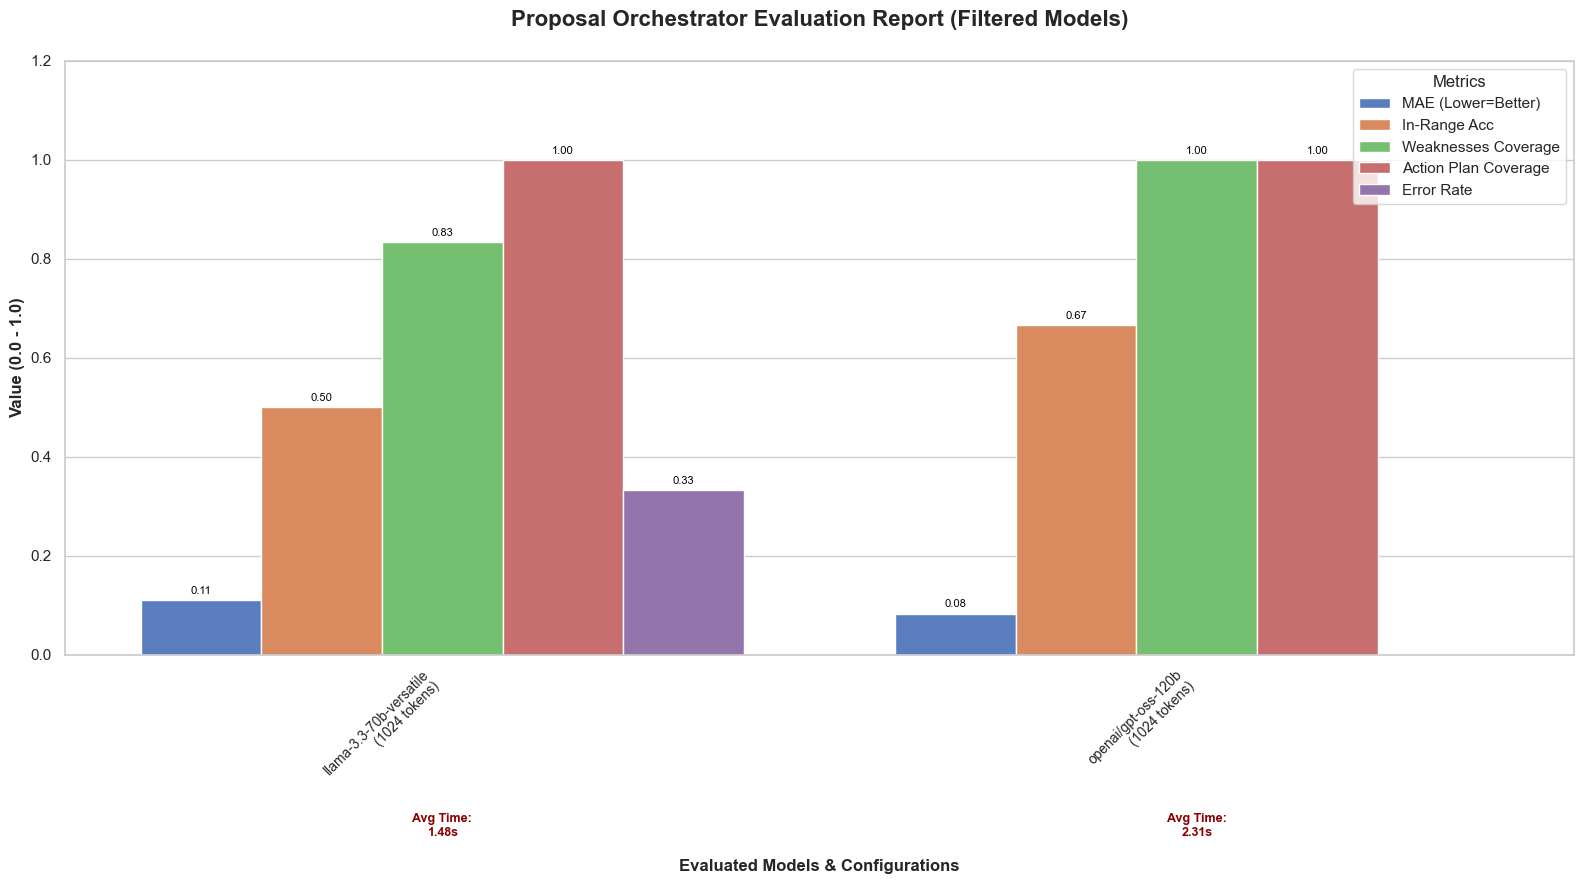

In [1]:
import json
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

JSON_FILE_NAME = "json_results/super_agent.json"  

if not os.path.exists(JSON_FILE_NAME):
    raise FileNotFoundError(f"Result file {JSON_FILE_NAME} not found.")

with open(JSON_FILE_NAME, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

parsed_runs = []
for run in raw_data:
    model_name = run.get("model_name", "Unknown").split(":")[-1] 
    max_tokens = run.get("model_kwargs", {}).get("max_tokens", 0)
    results = run.get("results", {})
    
    model_tag = f"{model_name}\n({max_tokens} tokens)"
    
    parsed_runs.append({
        "Model": model_tag,
        "MAE (Lower=Better)": results.get("orchestrator_score_mae", 0.0),
        "In-Range Acc": results.get("orchestrator_score_in_range_accuracy", 0.0),
        "Weaknesses Coverage": results.get("weaknesses_coverage_ratio", 0.0),
        "Action Plan Coverage": results.get("action_plan_coverage_ratio", 0.0),
        "Error Rate": results.get("error_rate", 0.0),
        "Time (s)": results.get("agent_invocation_time", 0.0)
    })

df = pd.DataFrame(parsed_runs)

df_grouped = df.groupby("Model", as_index=False).mean()

# Filter out any model configurations where the average Error Rate is exactly 1.0
df_grouped = df_grouped[df_grouped["Error Rate"] < 1.0].reset_index(drop=True)

df_melted = pd.melt(
    df_grouped, 
    id_vars=["Model", "Time (s)"], 
    value_vars=["MAE (Lower=Better)", "In-Range Acc", "Weaknesses Coverage", "Action Plan Coverage", "Error Rate"],
    var_name="Metric", 
    value_name="Score"
)

plt.figure(figsize=(16, 9))
sns.set_theme(style="whitegrid")

ax = sns.barplot(x="Model", y="Score", hue="Metric", data=df_melted, palette="muted")

for p in ax.patches:
    height = p.get_height()
    if height > 0.01:
        ax.annotate(f'{height:.2f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=8, color='black',
                    xytext=(0, 3),
                    textcoords='offset points')

plt.title("Proposal Orchestrator Evaluation Report (Filtered Models)", fontsize=16, fontweight='bold', pad=25)
plt.ylabel("Value (0.0 - 1.0)", fontsize=12, fontweight='bold')
plt.ylim(0, 1.2) 
plt.legend(title="Metrics", loc="upper right", frameon=True)

plt.xlabel("Evaluated Models & Configurations", fontsize=12, fontweight='bold', labelpad=50)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)

for idx, row in df_grouped.iterrows():
    ax.text(idx, -0.32, f"Avg Time:\n{row['Time (s)']:.2f}s", 
            ha='center', va='top', fontsize=9, color='darkred', fontweight='bold')

plt.subplots_adjust(bottom=0.28)
plt.tight_layout()

plt.show()